# Multiclass classification

Run in order: **Data → Model → Training → Evaluation → Visualization**.

Extend week 3's logistic regression to the ten MNIST digit classes using **softmax regression**.

## 1. Data

MNIST contains 60,000 training images and 10,000 test images of handwritten digits.
Each grayscale image has $28\times28=784$ pixels and a label $y_i\in\{0,\ldots,9\}$.

Scale pixel values to $[0,1]$ and flatten each image into a vector $x_i\in\mathbb R^{784}$.
The random seed makes the training shuffle and parameter initialization reproducible.

This notebook requires `torch`, `torchvision`, and `matplotlib`. The first run downloads MNIST into `./data`; later runs reuse it. Keep the test set separate for final evaluation.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# 1. Load MNIST dataset
# ============================================================
torch.manual_seed(0)

data_dir = "./data"
train_data = datasets.MNIST(root=data_dir, train=True, download=True)
test_data = datasets.MNIST(root=data_dir, train=False, download=True)

x_train = train_data.data.reshape(-1, 784).float() / 255.0
y_train = train_data.targets.long()
x_test = test_data.data.reshape(-1, 784).float() / 255.0
y_test = test_data.targets.long()

N, D = x_train.shape
C = 10
batch_size = 256
train_loader = DataLoader(
    TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(0),
)

print(f"Training images: {N}, test images: {len(x_test)}")
print(f"Input features: {D}, classes: {C}")

Training images: 60000, test images: 10000
Input features: 784, classes: 10


### View the dataset

Each image is an input $x_i$; its title shows the digit label $y_i$.

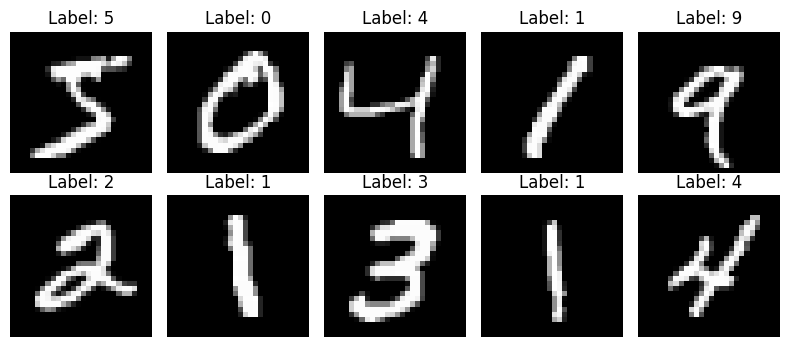

In [2]:
# ============================================================
# Plot dataset only
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].reshape(28, 28).numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {y_train[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Model

Predict one probability for each of the ten classes:

$$
z_i=x_iW+b,\qquad
p_{ic}=\operatorname{softmax}(z_i)_c
=\frac{e^{z_{ic}}}{\sum_{j=0}^{9}e^{z_{ij}}}.
$$

Here $W\in\mathbb R^{784\times10}$ and $b\in\mathbb R^{10}$. The class probabilities sum to one for each image.

Minimize multiclass cross-entropy with a weight penalty:

$$
\mathcal L(W,b)
=-\frac{1}{N}\sum_{i=1}^{N}\log p_{i,y_i}
+\frac{\lambda}{2}\sum_{d=1}^{784}\sum_{c=0}^{9}W_{dc}^{2}.
$$

The bias is not penalized. `CrossEntropyLoss` takes **raw logits** and integer labels, without applying softmax first. Unlike week 3's binary model, each image now has ten scores instead of one.

In [3]:
lam = 1e-4
ce_loss = nn.CrossEntropyLoss()


def compute_loss(w, b, x_batch, y_batch):
    logits = x_batch @ w + b
    data_loss = ce_loss(logits, y_batch)
    reg_loss = 0.5 * lam * torch.sum(w ** 2)
    return data_loss + reg_loss


w = (0.01 * torch.randn(D, C)).requires_grad_()
b = torch.zeros(C, requires_grad=True)

## 3. Training

Update the parameters using gradient descent:

$$
\theta\leftarrow\theta-\eta\nabla\mathcal L_{\mathrm{batch}}(\theta).
$$

As in week 3, `backward()` computes gradients and `zero_()` clears them after each update.
Here we use shuffled **mini-batches** because MNIST is larger than the toy dataset. One epoch visits every training image once.

Record the sample-weighted mean of the losses computed before each batch update. This is a training trajectory, not the loss of a single fixed parameter vector. Set `print_every = 1` to print every epoch.

In [4]:
lr = 0.1
num_epochs = 20
print_every = 1

loss_history = []
num_updates = 0

for epoch in range(num_epochs):
    total_loss = 0.0

    for x_batch, y_batch in train_loader:
        # Compute loss before the update.
        loss = compute_loss(w, b, x_batch, y_batch)
        total_loss += loss.item() * len(x_batch)

        # Backpropagation
        loss.backward()

        # Gradient descent update
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad

        # Reset gradients.
        w.grad.zero_()
        b.grad.zero_()
        num_updates += 1

    loss_history.append(total_loss / N)
    if (epoch + 1) % print_every == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch + 1:2d}: mean batch loss = {loss_history[-1]:.6f}")

w_gd = w.detach().clone()
b_gd = b.detach().clone()

print(f"\nCompleted {num_updates} gradient descent updates.")
print(f"W shape: {tuple(w_gd.shape)}, b shape: {tuple(b_gd.shape)}")

Epoch  1: mean batch loss = 0.711718
Epoch  2: mean batch loss = 0.430922
Epoch  3: mean batch loss = 0.385867
Epoch  4: mean batch loss = 0.363381
Epoch  5: mean batch loss = 0.349039
Epoch  6: mean batch loss = 0.338963
Epoch  7: mean batch loss = 0.331367
Epoch  8: mean batch loss = 0.325177
Epoch  9: mean batch loss = 0.320288
Epoch 10: mean batch loss = 0.316238
Epoch 11: mean batch loss = 0.312598
Epoch 12: mean batch loss = 0.309609
Epoch 13: mean batch loss = 0.306985
Epoch 14: mean batch loss = 0.304635
Epoch 15: mean batch loss = 0.302486
Epoch 16: mean batch loss = 0.300583
Epoch 17: mean batch loss = 0.298913
Epoch 18: mean batch loss = 0.297289
Epoch 19: mean batch loss = 0.295924
Epoch 20: mean batch loss = 0.294593

Completed 4700 gradient descent updates.
W shape: (784, 10), b shape: (10,)


## 4. Evaluation

Predict the class with the largest probability:

$$
\hat y_i=\operatorname*{arg\,max}_{c\in\{0,\ldots,9\}}p_{ic}.
$$

Softmax preserves the ordering of logits, so taking `argmax` of logits gives the same prediction.
Report the final regularized training loss, training accuracy, and **held-out test accuracy**. Test cross-entropy below excludes the weight penalty.

In [5]:
with torch.no_grad():
    final_loss = compute_loss(w_gd, b_gd, x_train, y_train).item()
    train_pred = (x_train @ w_gd + b_gd).argmax(dim=1)
    train_accuracy = (train_pred == y_train).float().mean().item()

    test_logits = x_test @ w_gd + b_gd
    test_prob = torch.softmax(test_logits, dim=1)
    test_pred = test_prob.argmax(dim=1)
    test_accuracy = (test_pred == y_test).float().mean().item()
    test_loss = ce_loss(test_logits, y_test).item()

print(f"Loss after {num_updates} updates: {final_loss:.6f}")
print(f"Training accuracy: {100 * train_accuracy:.1f}%")
print(f"Test cross-entropy: {test_loss:.6f}")
print(f"Test accuracy: {100 * test_accuracy:.1f}%")

Loss after 4700 updates: 0.292832
Training accuracy: 92.0%
Test cross-entropy: 0.282456
Test accuracy: 92.1%


## 5. Visualization

The left panel shows the training loss across epochs. The right panel shows the ten predicted probabilities for the first test image.
The image grid shows predictions for the first ten test images; red titles mark mistakes.

**Question:** How does softmax extend week 3's sigmoid probability to ten classes? Does a high predicted probability always mean the prediction is correct?

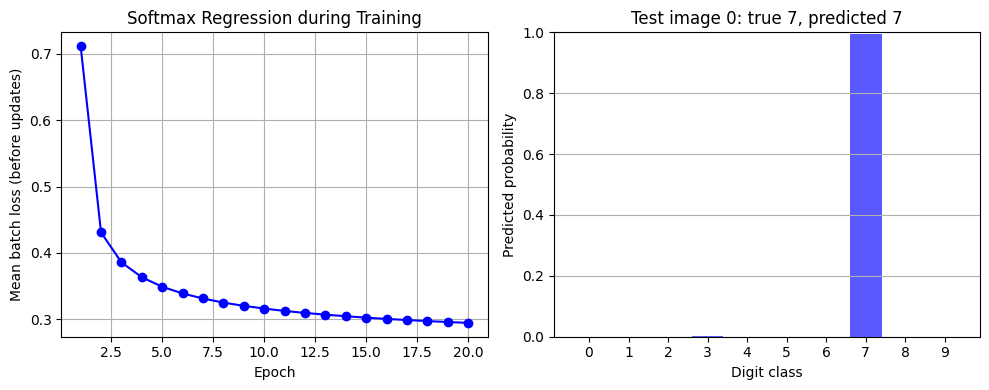

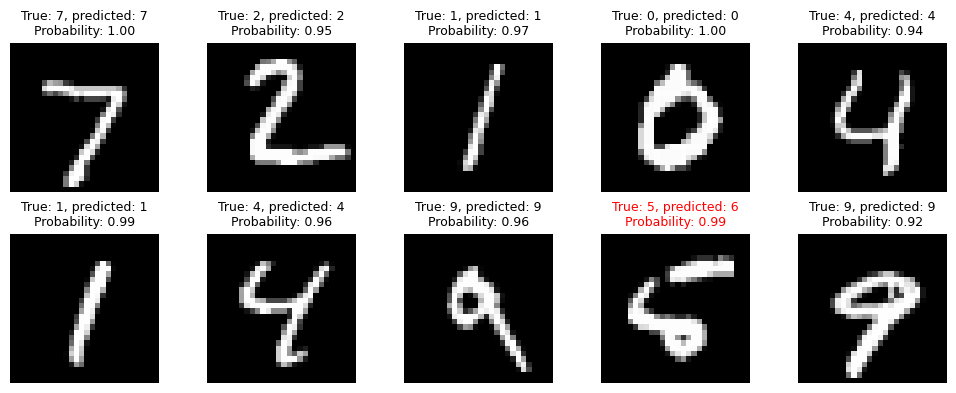

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: training loss trajectory.
ax = axes[0]
ax.plot(range(1, num_epochs + 1), loss_history, color="blue", marker="o")
ax.set_title("Softmax Regression during Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean batch loss (before updates)")
ax.grid(True)

# Right: class probabilities for one test image.
sample_idx = 0
ax = axes[1]
ax.bar(range(C), test_prob[sample_idx].numpy(), color="blue", alpha=0.65)
ax.set_title(f"Test image {sample_idx}: true {y_test[sample_idx].item()}, "
             f"predicted {test_pred[sample_idx].item()}")
ax.set_xlabel("Digit class")
ax.set_ylabel("Predicted probability")
ax.set_xticks(range(C))
ax.set_ylim(0, 1)
ax.grid(True, axis="y")

# ============================================================
# 5. Save and show
# ============================================================
plt.tight_layout()
fig.savefig("multiclass_gd_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    predicted = test_pred[i].item()
    actual = y_test[i].item()
    confidence = test_prob[i, predicted].item()
    ax.imshow(x_test[i].reshape(28, 28).numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"True: {actual}, predicted: {predicted}\n"
                 f"Probability: {confidence:.2f}",
                 color="black" if predicted == actual else "red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
fig.savefig("multiclass_mnist_predictions.png", dpi=300, bbox_inches="tight")
plt.show()